In [1]:
from pathlib import Path
import cv2
import numpy as np
from matplotlib import pyplot as plt

from PIL import Image
from IPython.display import display

In [2]:
data_dir = Path("../.data/LV_1").resolve()
assert data_dir.exists(), f"Data directory {data_dir} does not exist."
sorted(list(map(lambda p: p.name, data_dir.glob("*"))))

['0001.png',
 '0002.png',
 '0003.png',
 '0004.png',
 '0005.png',
 '0006.png',
 '0007.png',
 '0008.png',
 '0009.png',
 'HM_Karlstr.jpg',
 'out.mp4',
 'shaky_car.avi',
 'trafficScene.avi']

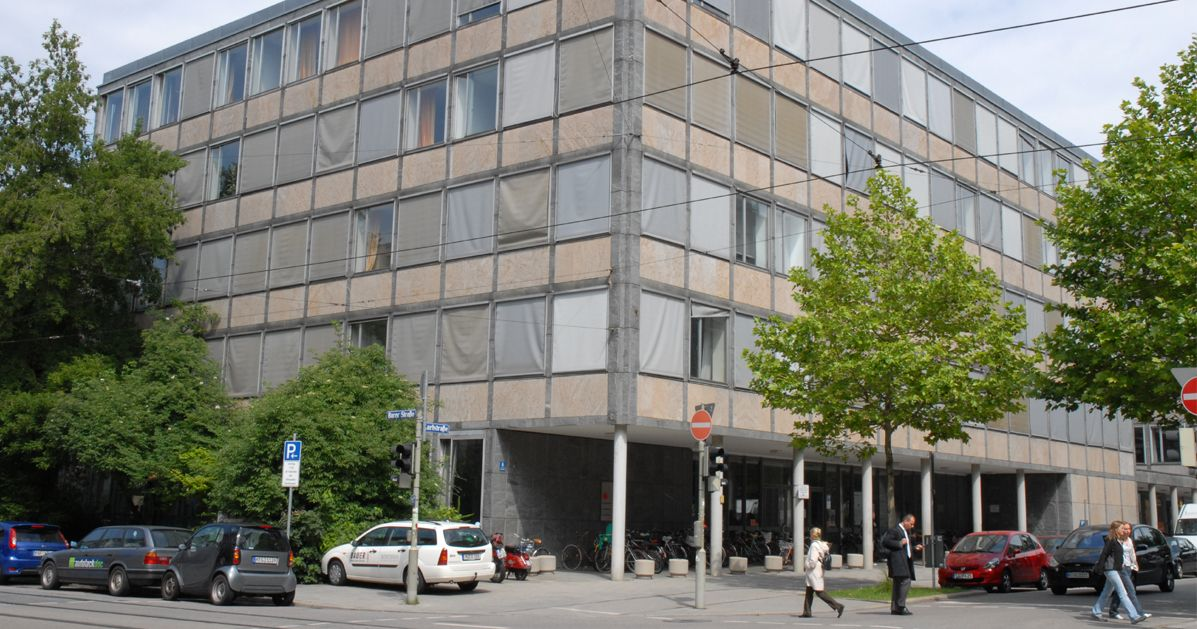

In [3]:
hm_img = Image.open(data_dir / "HM_Karlstr.jpg")
display(hm_img)

In [4]:
print("width: {}, height: {}, #chs: {}".format(*hm_img.size, len(hm_img.getbands())))

hm_img_np = np.array(hm_img)
print("height: {}, width: {}, #chs: {}".format(*hm_img_np.shape))

width: 1197, height: 629, #chs: 3
height: 629, width: 1197, #chs: 3


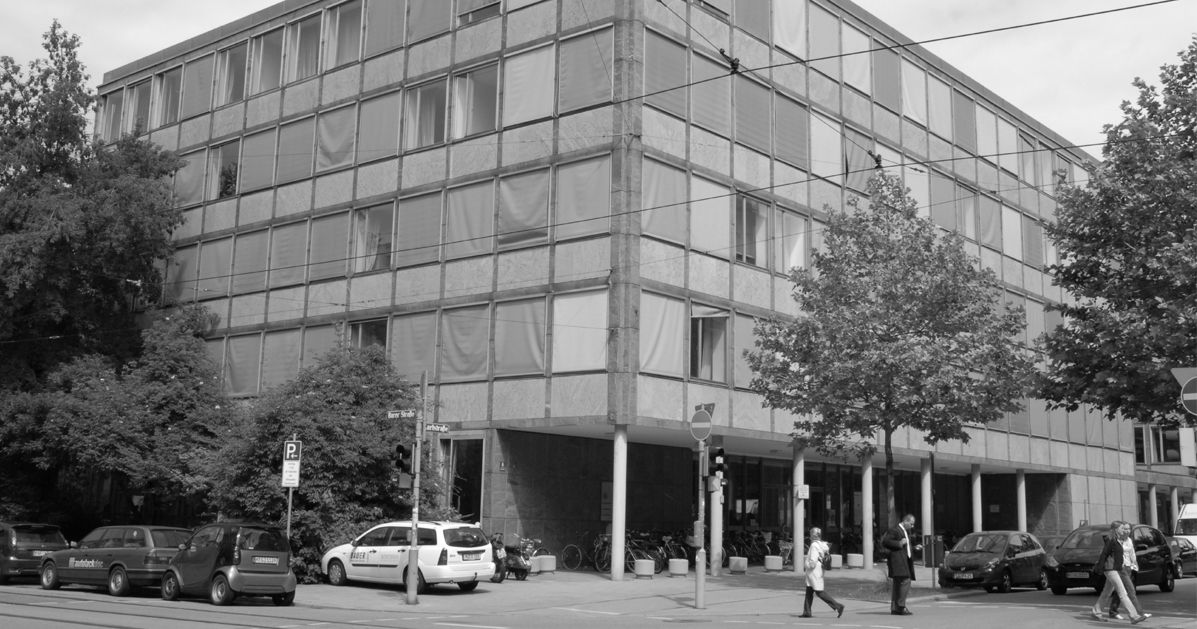

In [5]:
# convert to grayscale
hm_img_gray = hm_img.convert("L")
display(hm_img_gray)

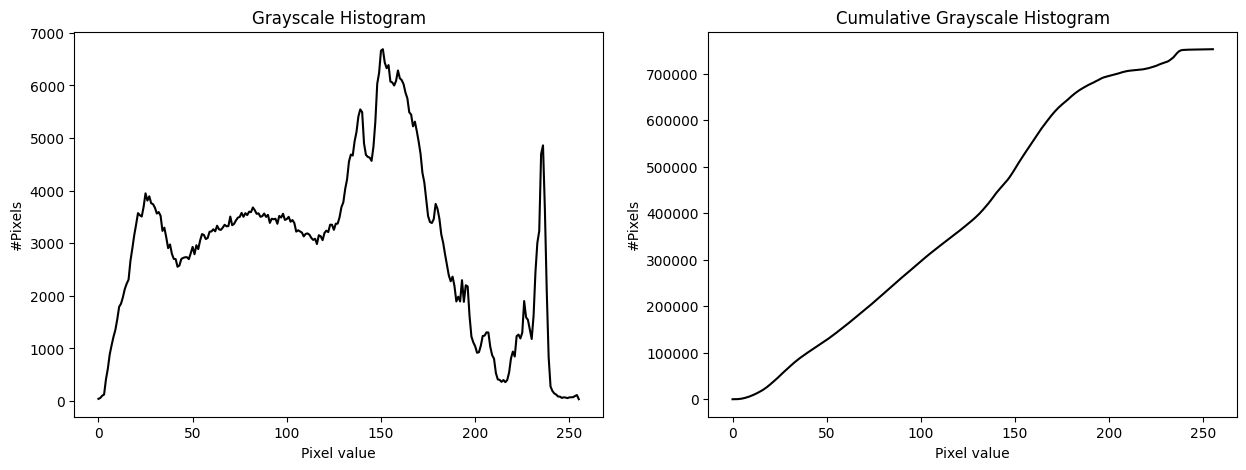

In [6]:
# compute and plot grayscale and rgb histograms
hm_img_gray_np = np.array(hm_img_gray)
hist_gray = cv2.calcHist([hm_img_gray_np], channels=[0], mask=None, histSize=[256], ranges=[0, 256], accumulate=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.set_title("Grayscale Histogram")
ax1.set_xlabel("Pixel value")
ax1.set_ylabel("#Pixels")
ax1.plot(hist_gray, color='k')

# cumulative histogram
hist_gray_cum = hist_gray.cumsum()
ax2.set_title("Cumulative Grayscale Histogram")
ax2.set_xlabel("Pixel value")
ax2.set_ylabel("#Pixels")
ax2.plot(hist_gray_cum, color='k')
plt.show()

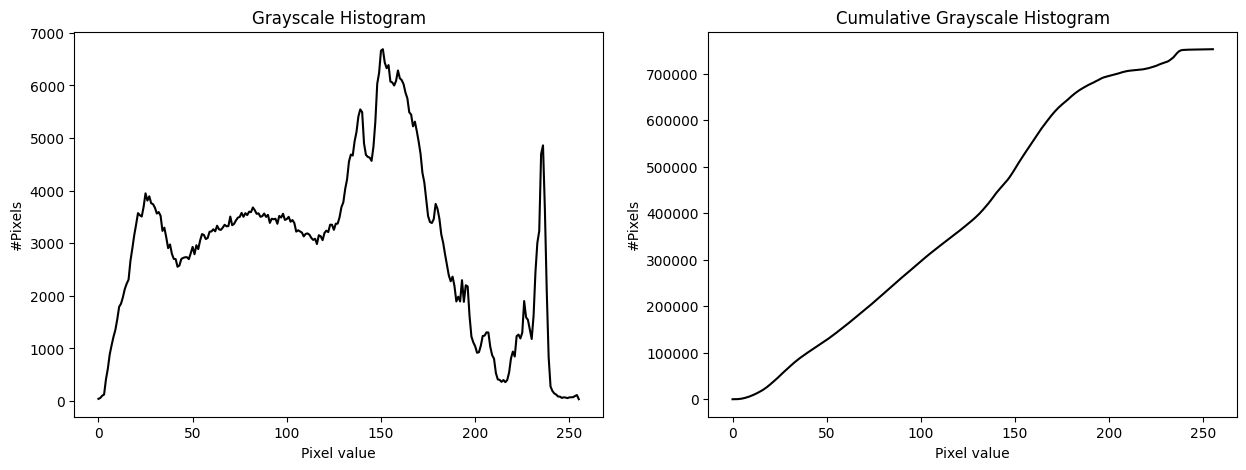

In [7]:
# compute and plot grayscale and rgb histograms
hm_img_gray_np = np.array(hm_img_gray)
hist_gray = cv2.calcHist([hm_img_gray_np], channels=[0], mask=None, histSize=[256], ranges=[0, 256], accumulate=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.set_title("Grayscale Histogram")
ax1.set_xlabel("Pixel value")
ax1.set_ylabel("#Pixels")
ax1.plot(hist_gray, color='k')

# cumulative histogram
hist_gray_cum = hist_gray.cumsum()
ax2.set_title("Cumulative Grayscale Histogram")
ax2.set_xlabel("Pixel value")
ax2.set_ylabel("#Pixels")
ax2.plot(hist_gray_cum, color='k')
plt.show()

- white car is likely represented by the sharp peak at around 230
- CDF is relatively smooth, indicating a good exposure range
- the first peak around 30 likely corresponds to elements of the dark cars the black suite
- then the relatively dark vegitation and the shadowed areas followed by a huge peak around 150 likely representing the building and road surface

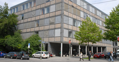

In [8]:
display(hm_img.resize((np.array(hm_img.size) * 0.1).astype(int)))

width: 1197, height: 629


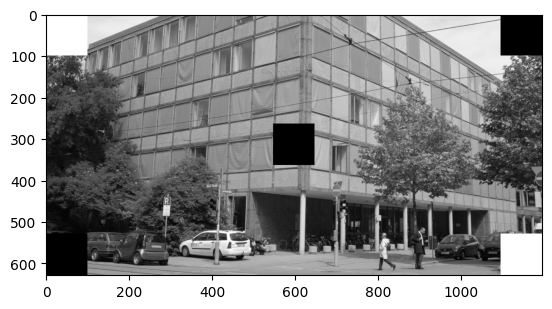

In [9]:
width, height = hm_img.size
print(f"width: {width}, height: {height}")

hm_img_gray_np_mod = hm_img_gray_np.copy()
# center
hm_img_gray_np_mod[height // 2 - 50:height // 2 + 50, width // 2 - 50:width // 2 + 50] = 0
# top-left
hm_img_gray_np_mod[0:100, 0:100] = 255
# bottom-right
hm_img_gray_np_mod[height - 100:height, width - 100:width] = 255
# bottom-left
hm_img_gray_np_mod[height - 100:height, 0:100] = 0
# top-right
hm_img_gray_np_mod[0:100, width - 100:width] = 0
plt.imshow(hm_img_gray_np_mod, cmap='gray')
plt.show()

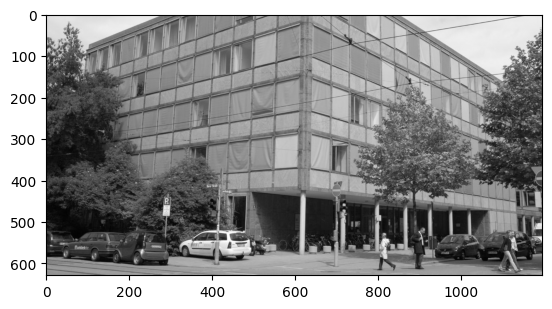

In [10]:
plt.imshow(hm_img_gray_np, cmap='gray')

In [11]:
from pathlib import Path
import numpy as np
import cv2
from PIL import Image, ImageOps

# settings
pattern = "000[1-9].png"
out_path = data_dir / "out.mp4"
fps = 1
codec = "mp4v"

# collect & sort files
files = sorted(data_dir.glob(pattern), key=lambda p: p.name)
assert len(files)

im0 = ImageOps.exif_transpose(Image.open(files[0])).convert("RGB")
frame0 = cv2.cvtColor(np.array(im0), cv2.COLOR_RGB2BGR)
H, W = frame0.shape[:2]

# writer
fourcc = cv2.VideoWriter_fourcc(*codec)
vw = cv2.VideoWriter(out_path.as_posix(), fourcc, fps, (W, H))

for fp in files:
    im = ImageOps.exif_transpose(Image.open(fp)).convert("RGB")
    bgr = cv2.cvtColor(np.array(im), cv2.COLOR_RGB2BGR)
    vw.write(bgr)
vw.release()
print(f"Saved {len(files)} frames to {out_path} at {fps} fps.")

Saved 9 frames to /Users/jd/Desktop/repos/mobile-mapping/.data/LV_1/out.mp4 at 1 fps.


In [16]:
out_path.exists()

True

In [18]:
from IPython.display import Video
Video(out_path, embed=True, width=600)

In [21]:
import open3d as o3d

pth = data_dir.parent / "LV_2" / "teapotOut.ply"
assert pth.exists(), pth

In [22]:
pcd = o3d.io.read_point_cloud(pth)
print(pcd)

PointCloud with 41472 points.


In [23]:
pts = np.asarray(pcd.points)
print(pts.shape, pts.dtype)

(41472, 3) float64


In [24]:
o3d.visualization.draw_geometries([pcd])